# Next week's crime, by community area: 1-week walkthrough

The 4-week walkthrough (`walkthrough.ipynb`) asked whether an area is about to run above its own normal over the next
month. This one asks it for **next week**, the horizon a resident checking the app cares about. It started as an
outside design (H3 cells, a 7-day horizon, classify "up or down vs last week"), which was reworked before anything was
built (section 1). The notebook reads the outputs the step scripts already wrote and runs top to bottom in about 10
seconds, including every leakage check.

| Step | Script | Output |
|---|---|---|
| 1 | `weather.py` | observed weather since 1996, archived 1–7 day forecasts, a holiday calendar |
| 2 | `city_level.py` | next week's citywide total: momentum, calendar, weather |
| 3 | `local_week.py` | which r8 cells run hot or cold relative to the city, plus a fresher-311 test |
| 4 | `area_week.py` | a forecast and an up/down call for each of the 77 community areas |

### Short version
- **"Next week vs last week" is the wrong target.** Regression to the mean alone scores 71–77% on it. The target
  stays "above the area's own normal."
- **At one week, a fifth of an area's miss is the whole city running hot or cold.** A citywide model wins most of that:
  - its pieces are recent momentum, holidays, and the real 1–7 day weather forecast
  - area × week deviance skill is +11.8%
  - the weather forecast alone adds +3.7%, nearly all that perfect weather knowledge would
- **The local lean adds ~3% more.** 311 adds nothing, even when it's a week fresher than crime.
- **Calls:** 23% of area-weeks get an up/down call, right 75% of the time against a 48% base rate. Most of that
  is the citywide call, and calls in the same week stand or fall together.

In [1]:
# The notebook lives in offline_ml/ and borrows helpers from the step scripts beside it.
import logging
import sys
from datetime import timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from h3.api import basic_int as h3
from matplotlib.collections import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

sys.path.insert(0, str(Path.cwd()))
from config import CLEAN, PANEL, REPORT_LAG_DAYS, TEST_START, WEATHER, WEEK_MODEL

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)   # no "semibold" fallback notices
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_float_precision(3)
pl.Config.set_tbl_rows(30)
pl.Config.set_fmt_str_lengths(60)
pl.Config.set_tbl_width_chars(160)
pl.Config.set_tbl_cols(16)

# Chart palette: the validated reference palette, light surface (same as walkthrough.ipynb).
SURFACE, INK, INK_2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#8a8984", "#e4e3df"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"          # categorical slots 1-3
UP, DOWN, NEUTRAL = "#e34948", "#2a78d6", "#f0efec"            # diverging poles + gray midpoint

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "xtick.color": INK_2, "ytick.color": INK_2,
    "text.color": INK, "axes.titlecolor": INK, "axes.titlesize": 12, "axes.titleweight": "semibold",
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.grid": True, "grid.color": GRID,
    "grid.linewidth": 0.8, "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "font.size": 10, "legend.frameon": False, "figure.dpi": 110,
})


def hex_map(ax, cells, colors, edge=SURFACE, lw=0.4):
    """Draw H3 cells (int ids) as polygons, lng/lat with Chicago's aspect ratio."""
    polys = [[(lng, lat) for lat, lng in h3.cell_to_boundary(int(c))] for c in cells]
    ax.add_collection(PolyCollection(polys, facecolors=colors, edgecolors=edge, linewidths=lw))
    ax.autoscale_view()
    ax.set_aspect(1 / np.cos(np.radians(41.84)))
    ax.axis("off")


def forest(ax, labels, est, lo, hi, color=BLUE, ref=0.0):
    """Estimates with 95% intervals, first label on top, and a reference line."""
    y = np.arange(len(labels))[::-1]
    ax.hlines(y, lo, hi, color=color, lw=3)
    ax.plot(est, y, "o", color=color, ms=7, mec=SURFACE, mew=1.5)
    ax.axvline(ref, color=INK_2, lw=1)
    ax.set_yticks(y, labels)
    ax.grid(axis="y", visible=False)


pct = lambda ax: ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}" if v else "0"))

## 1. Why a week needs a different design

The outside design proposed classifying each H3 cell as "up or down vs the last 7 days." Two checks on the raw data
changed that.

**Check 1: "vs last week" mostly measures regression to the mean.** An unusually high week is usually followed by a
lower one, whatever the cause. So a rule with no model at all scores well: "call up if last week was below the area's
yearly average." The obvious baseline, "same direction as last week," scores *worse than a coin*, for the same reason.
A model would look great against it and have learned nothing useful.

In [2]:
# Weekly counts: r8 cells from the panel, community areas straight from the crime records.
cw = pl.read_parquet(PANEL / "crime_weekly.parquet")
last_week = cw["week"].max()
ca = (pl.read_parquet(CLEAN / "crimes.parquet", columns=["occurred_at", "community_area"])
      .filter(pl.col("community_area").is_not_null())
      .with_columns(pl.col("occurred_at").dt.truncate("1w").dt.date().alias("week"))
      .filter(pl.col("week").is_between(cw["week"].min(), last_week))
      .group_by("community_area", "week").agg(pl.len().alias("crime_n")))
ca = (ca.select("community_area").unique().join(cw.select("week").unique(), how="cross")
      .join(ca, on=["community_area", "week"], how="left").with_columns(pl.col("crime_n").fill_null(0)))
grains = {"r8 cell": cw.select(pl.col("h3_r8").alias("u"), "week", "crime_n"),
          "community area": ca.rename({"community_area": "u"})}


def vs_last_week(df):
    """Balanced accuracy on 'next week above last week' (ties dropped), 2022+ weeks."""
    d = df.sort("u", "week").with_columns(
        pl.col("crime_n").shift(-1).over("u").alias("nxt"), pl.col("crime_n").shift(1).over("u").alias("prev"),
        pl.col("crime_n").rolling_mean(52).over("u").alias("avg"))
    d = d.filter((pl.col("week") >= TEST_START) & pl.col("nxt").is_not_null() & pl.col("avg").is_not_null()
                 & pl.col("prev").is_not_null() & (pl.col("nxt") != pl.col("crime_n")))
    up = (d["nxt"] > d["crime_n"]).to_numpy()
    bacc = lambda pred: 0.5 * (pred[up].mean() + (~pred[~up]).mean())
    return {"mean-reversion rule": bacc((d["crime_n"] < d["avg"]).to_numpy()),
            "same direction as last week": bacc((d["crime_n"] > d["prev"]).to_numpy())}


pl.DataFrame([{"grain": g, **vs_last_week(df)} for g, df in grains.items()])

grain,mean-reversion rule,same direction as last week
str,f64,f64
"""r8 cell""",0.770,0.300
"""community area""",0.707,0.331


**Check 2: at one week, the whole city running hot or cold matters.** The chart splits the baseline's error (its
Poisson deviance) three ways:
- **chance:** what pure Poisson noise around the true rate would produce. No model can win it.
- **citywide level:** what knowing next week's actual citywide total would remove.
- **local:** everything else, an upper bound on what a local model could win.

The baseline here is the unit's trailing-year average × a citywide seasonal factor.

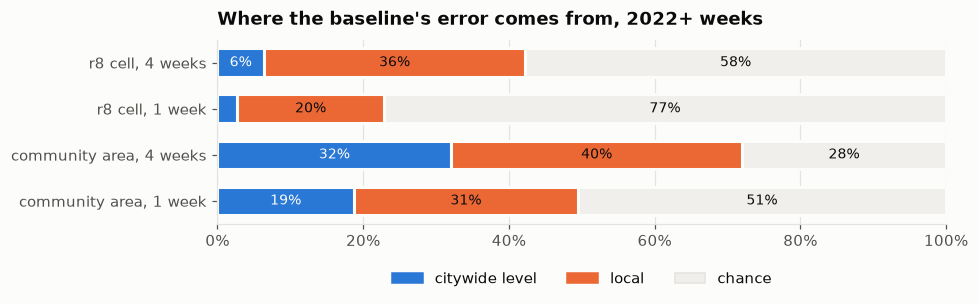

In [3]:
def pdev(y, mu):
    mu = np.maximum(mu, 1e-9)
    with np.errstate(divide="ignore", invalid="ignore"):
        return 2 * np.mean(np.where(y > 0, y * np.log(y / mu), 0) - (y - mu))


def decompose(df, weeks):
    d = df.sort("u", "week").with_columns(
        pl.col("crime_n").rolling_sum(weeks).shift(-weeks).over("u").alias("fut"),
        pl.col("crime_n").rolling_mean(52).over("u").alias("m52"))
    c = (d.group_by("week").agg(pl.col("fut").sum().alias("cfut"), pl.col("m52").sum().alias("cm52")).sort("week")
         .with_columns((pl.col("cfut") / (pl.col("cm52") * weeks)).alias("ratio"))
         .with_columns(pl.concat_list([pl.col("ratio").shift(52 * k) for k in range(1, 6)]).list.median().alias("sf")))
    d = d.join(c, on="week").filter((pl.col("week") >= TEST_START) & pl.col("fut").is_not_null()
                                    & pl.col("m52").is_not_null() & pl.col("sf").is_not_null())
    y, base = d["fut"].to_numpy().astype(float), d["m52"].to_numpy() * weeks
    bar, oracle = base * d["sf"].to_numpy(), base * d["ratio"].to_numpy()
    floor = np.mean([pdev(np.random.default_rng(s).poisson(oracle).astype(float), oracle) for s in range(3)])
    total = pdev(y, bar)
    return {"chance": floor / total, "citywide level": (total - pdev(y, oracle)) / total,
            "local": (pdev(y, oracle) - floor) / total}


rows = [(f"{g}, {w} week{'s' if w > 1 else ''}", decompose(df, w)) for g, df in grains.items() for w in (4, 1)]
parts = [("citywide level", BLUE), ("local", ORANGE), ("chance", NEUTRAL)]
fig, ax = plt.subplots(figsize=(9, 3.2))
for i, (label, shares) in enumerate(rows[::-1]):
    left = 0
    for name, color in parts:
        w = shares[name]
        ax.barh(i, w, left=left, color=color, edgecolor=SURFACE, linewidth=2, height=0.62)
        if w > 0.05:
            ax.text(left + w / 2, i, f"{w:.0%}", ha="center", va="center", fontsize=9,
                    color=SURFACE if color == BLUE else INK)
        left += w
ax.set_yticks(range(len(rows)), [r[0] for r in rows[::-1]])
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis="y", visible=False)
ax.set_title("Where the baseline's error comes from, 2022+ weeks")
ax.legend(handles=[Patch(facecolor=c, edgecolor=GRID if c == NEUTRAL else c, label=n) for n, c in parts],
          loc="lower center", bbox_to_anchor=(0.5, -0.42), ncols=3)
fig.tight_layout()

- **Chance dominates small units and short windows.** It's about three-quarters of an r8 cell's weekly miss, and
  half of a community area's.
- **The citywide level barely matters for a cell over 4 weeks, but it's ~19% of an area's weekly miss.** That's why
  the 4-week track could let the baseline set the citywide total, and why this track models it first.

So the design is:
- **Target:** will an area beat its own normal next week?
- **Citywide:** a model for the whole city's level (step 2).
- **Local:** a model for which places run hot or cold relative to the city (step 3).
- **Calls:** made for community areas, the grain the app shows (step 4).

## 2. The reporting lag is part of the design

The live crime feed runs behind. On 2026-09-26, its newest complete day was 09-17, with 09-18 part-loaded. A forecast
made on cutoff Monday *c* therefore can't see the week just before it:

```
 crime:  ... 364 days ... 28 days ... 7 days |  not in the feed yet  | c | → target: all crime in the next 7 days
                                           c − 8                     c
 311:    ... 364 days ... 28 days ... 7 days ........................| c − 1
```

- **Every crime feature ends 8 days before the cutoff** (`REPORT_LAG_DAYS`).
- **So do the training folds.** A fold trains only on target weeks already in the feed at its first test cutoff,
  which is 3 weeks back.
- **The 311 feed is near real time.** On 2026-09-26 it already held that morning's requests, so its features run to
  the day before the cutoff. Step 3 tests whether that head start helps.
- **Days first appear ~98% complete** and fill in to ~99.5% over two weeks. The backtest uses final counts, so live
  momentum reads ~1.5% low, which lowers live forecasts by roughly 0.5%. That isn't corrected yet.

## 3. Weather: the forecast that was really issued

Open-Meteo keeps an archive of past forecasts: for every hour, what the run from 1–7 days earlier said. So each test
week can get the forecast issued the day before its cutoff, not the weather that actually happened. Using observed
weather in a backtest would be a leak.
- **Anomalies:** measured against a 10-year normal (the same date ±7 days, previous years only).
- **Temperature:** GFS, whose archive starts in 2021.
- **Precipitation:** JMA, the only archive with precipitation back to 2021.

┌──────────────┬───────┬─────────────┬────────────┬──────────────────┬───────────────────┬─────────────────────┐
│ model        ┆ weeks ┆ temp_bias_C ┆ temp_mae_C ┆ obs_anomaly_sd_C ┆ temp_anomaly_corr ┆ precip_anomaly_corr │
│ ---          ┆ ---   ┆ ---         ┆ ---        ┆ ---              ┆ ---               ┆ ---                 │
│ str          ┆ u32   ┆ f64         ┆ f64        ┆ f64              ┆ f64               ┆ f64                 │
╞══════════════╪═══════╪═════════════╪════════════╪══════════════════╪═══════════════════╪═════════════════════╡
│ gfs_seamless ┆ 242   ┆ 0.580       ┆ 1.030      ┆ 3.240            ┆ 0.942             ┆ 0.394               │
│ jma_seamless ┆ 244   ┆ -0.940      ┆ 1.870      ┆ 3.290            ┆ 0.762             ┆ 0.443               │
│ used         ┆ 246   ┆ 0.590       ┆ 1.040      ┆ 3.300            ┆ 0.944             ┆ 0.443               │
└──────────────┴───────┴─────────────┴────────────┴──────────────────┴───────────────────┴──────

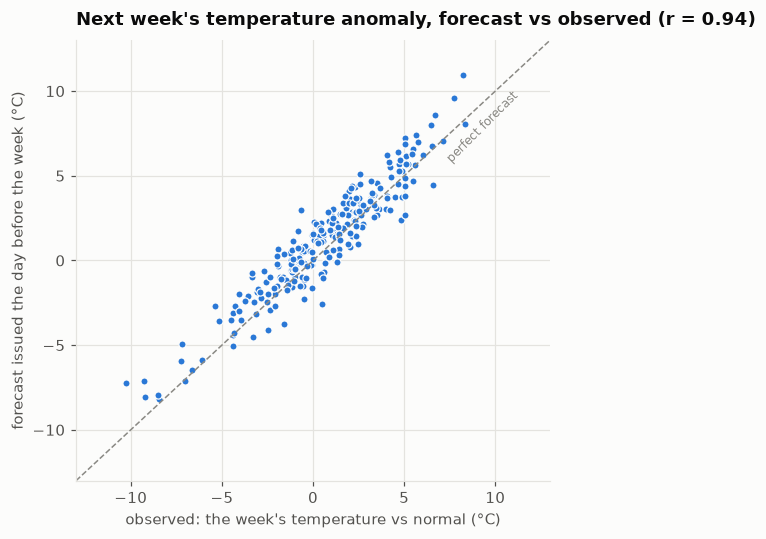

In [4]:
from weather import forecast_skill
from city_level import weekly_weather

obs_daily = pl.read_parquet(WEATHER / "observed_daily.parquet")
fc_daily = pl.read_parquet(WEATHER / "forecast_daily.parquet")
print(forecast_skill(obs_daily, fc_daily))

observed, forecast = weekly_weather()
wk = (observed.join(forecast, on="cutoff", suffix="_fc")
      .filter((pl.col("cutoff") >= TEST_START) & (pl.col("cutoff").dt.weekday() == 1)).drop_nulls(["t_anom", "t_anom_fc"]))
r = np.corrcoef(wk["t_anom"], wk["t_anom_fc"])[0, 1]
fig, ax = plt.subplots(figsize=(5.2, 5.0))
lim = [-13, 13]
ax.plot(lim, lim, color=MUTED, lw=1, ls="--")
ax.text(7.2, 5.8, "perfect forecast", color=MUTED, fontsize=8, rotation=45)
ax.scatter(wk["t_anom"], wk["t_anom_fc"], s=22, color=BLUE, edgecolor=SURFACE, linewidth=0.8)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("observed: the week's temperature vs normal (°C)")
ax.set_ylabel("forecast issued the day before the week (°C)")
ax.set_title(f"Next week's temperature anomaly, forecast vs observed (r = {r:.2f})")
fig.tight_layout()

The 1–7 day forecast catches warm and cold weeks well. The anomaly correlation is 0.94, with a small warm bias
(+0.6 °C). That's the first hint that forecast weather will do nearly as well as perfect weather.

## 4. Step 2: next week's citywide total

`city_level.py` starts from the city's bar: its trailing-year daily rate × a daily seasonal factor. The factor is the
median of the same weekday's ratio 1–5 years back, ±1 week. A Poisson GLM on top adds:
- **momentum:** how far the last 7 and 28 known days ran from their own bar
- **calendar:** holiday flags, plus the 1st of the month (where "sometime this month" records are stamped)
- **weather:** the forecast anomalies for the target week, and the observed anomaly over the momentum window, so a
  hot week isn't mistaken for an upturn

It trains on observed weather back to 2007, skips COVID, and is walked forward quarterly over 244 test weeks. First,
the two leakage checks, run live:

In [5]:
# Both raise if a feature could see past its cutoff (~3 s).
import city_level
city, area_daily, last_full = city_level.load_daily()
city_rows, _ = city_level.build(city)
city_level.check_against_raw(city, city_rows)
city_level.check_future_deleted(city, city_rows)
print("city_level leakage checks passed: a raw recount of target, bar and momentum, and a rebuild with 2024-06-03+ deleted")

city_level leakage checks passed: a raw recount of target, bar and momentum, and a rebuild with 2024-06-03+ deleted


┌───────────────────┬──────────────┬────────┬───────┬───────┬─────────────────┐
│ model             ┆ skill_vs_ref ┆ ci_lo  ┆ ci_hi ┆ mape  ┆ swing_explained │
│ ---               ┆ ---          ┆ ---    ┆ ---   ┆ ---   ┆ ---             │
│ str               ┆ f64          ┆ f64    ┆ f64   ┆ f64   ┆ f64             │
╞═══════════════════╪══════════════╪════════╪═══════╪═══════╪═════════════════╡
│ bar_raw           ┆ -0.052       ┆ -0.158 ┆ 0.107 ┆ 0.061 ┆ 0.014           │
│ bar_calibrated    ┆ 0.000        ┆ 0.000  ┆ 0.000 ┆ 0.062 ┆ 0.000           │
│ momentum          ┆ 0.406        ┆ 0.205  ┆ 0.529 ┆ 0.048 ┆ 0.399           │
│ momentum_calendar ┆ 0.435        ┆ 0.218  ┆ 0.576 ┆ 0.047 ┆ 0.426           │
│ full_forecast     ┆ 0.613        ┆ 0.400  ┆ 0.739 ┆ 0.041 ┆ 0.629           │
│ full_observed     ┆ 0.622        ┆ 0.464  ┆ 0.725 ┆ 0.040 ┆ 0.625           │
│ no_momentum       ┆ 0.141        ┆ -0.086 ┆ 0.287 ┆ 0.063 ┆ 0.174           │
│ no_calendar       ┆ 0.576        ┆ 0.3

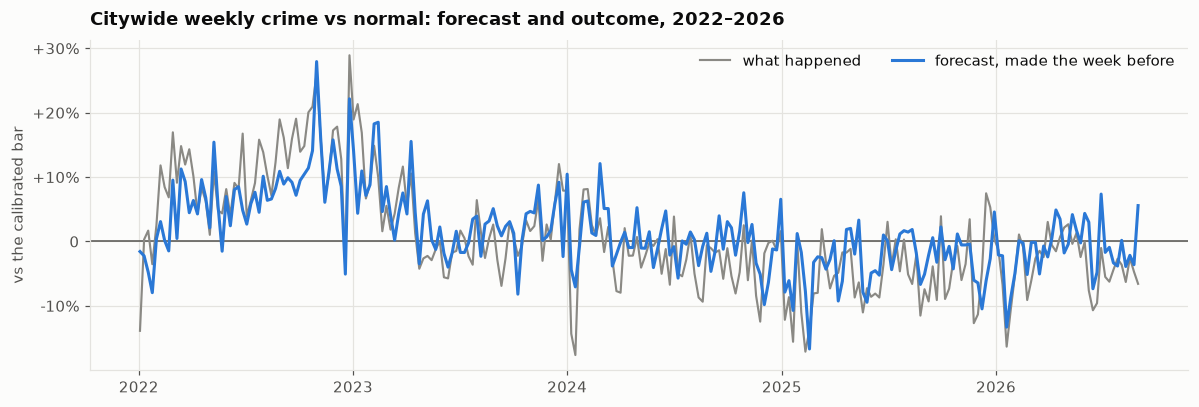

In [6]:
cp = pl.read_parquet(WEEK_MODEL / "city_predictions.parquet").sort("cutoff")
dep = lambda col: (cp[col] / cp["bar_calibrated"] - 1).to_numpy()
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.axhline(0, color=INK_2, lw=1)
ax.plot(cp["cutoff"], dep("y"), color=MUTED, lw=1.4, label="what happened")
ax.plot(cp["cutoff"], dep("full_forecast"), color=BLUE, lw=2, label="forecast, made the week before")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}" if v else "0"))
ax.set_ylabel("vs the calibrated bar")
ax.set_title("Citywide weekly crime vs normal: forecast and outcome, 2022–2026")
ax.legend(loc="upper right", ncols=2)
fig.tight_layout()

summary = pl.read_csv(WEEK_MODEL / "city_summary.csv")
print(summary.filter(pl.col("grain") == "city").select("model", "skill_vs_ref", "ci_lo", "ci_hi", "mape", "swing_explained"))

The forecast follows most of the swings: the 2022 climb, warm and cold spells, the holiday dips. Its weekly error
drops from 6.2% (the calibrated bar) to 4.1%. The biggest misses are single weeks it only partly caught, like the
sharp dip in January 2024.

What matters for the app is the payoff at **community area × week**: each area's own bar scaled by the city
multiplier. Each piece is added in turn and paired against the variant before it, with 95% CIs from resampling
whole quarters:

┌─────────────────────┬──────────────┬───────┬───────┐
│ model               ┆ skill_vs_ref ┆ ci_lo ┆ ci_hi │
│ ---                 ┆ ---          ┆ ---   ┆ ---   │
│ str                 ┆ f64          ┆ f64   ┆ f64   │
╞═════════════════════╪══════════════╪═══════╪═══════╡
│ full_forecast       ┆ 0.118        ┆ 0.055 ┆ 0.187 │
│ full_observed       ┆ 0.119        ┆ 0.061 ┆ 0.183 │
│ oracle_city         ┆ 0.192        ┆ 0.132 ┆ 0.254 │
│ poisson_noise_floor ┆ 0.503        ┆ null  ┆ null  │
└─────────────────────┴──────────────┴───────┴───────┘
┌───────────────────┬───────────────────────────────────────────┬────────────┐
│ feature           ┆ step                                      ┆ pct_effect │
│ ---               ┆ ---                                       ┆ ---        │
│ str               ┆ str                                       ┆ f64        │
╞═══════════════════╪═══════════════════════════════════════════╪════════════╡
│ hol_christmas     ┆ the target week has it           

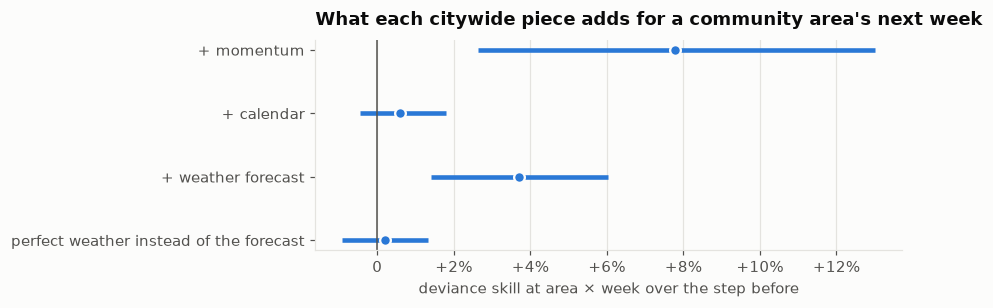

In [7]:
marg = pl.read_csv(WEEK_MODEL / "city_marginal.csv")
labels = {"momentum": "+ momentum", "calendar": "+ calendar", "weather forecast": "+ weather forecast",
          "perfect weather instead": "perfect weather instead of the forecast"}
fig, ax = plt.subplots(figsize=(8.4, 2.9))
forest(ax, [labels[p] for p in marg["piece"]], marg["area_week"], marg["area_week_lo"], marg["area_week_hi"])
pct(ax)
ax.set_xlabel("deviance skill at area × week over the step before")
ax.set_title("What each citywide piece adds for a community area's next week")
fig.tight_layout()

area_rows = summary.filter(pl.col("grain") == "area_week").select("model", "skill_vs_ref", "ci_lo", "ci_hi")
print(area_rows.filter(pl.col("model").is_in(["full_forecast", "full_observed", "oracle_city", "poisson_noise_floor"])))
coefs = pl.read_csv(WEEK_MODEL / "city_coefficients.csv")
print(coefs.filter(~pl.col("feature").str.starts_with("hol_") | pl.col("feature").is_in(
    ["hol_thanksgiving", "hol_christmas", "hol_christmas_eve", "hol_new_years_eve", "hol_halloween", "hol_easter"]))
      .sort(pl.col("pct_effect").abs(), descending=True).select("feature", "step", "pct_effect"))

- **Momentum is the biggest piece** (+7.8%). Partly this is the trailing-year bar lagging real multi-month trends.
- **The weather forecast is next** (+3.7%, CI +1.3 to +6.1%). Perfect weather would add only +0.2% more. That's
  about +1% crime per °C above normal, and −0.4% per extra cm of rain.
- **The calendar is small overall** (+0.6%, not significant), though single weeks move:
  - Thanksgiving −3%, New Year's Eve +7%.
  - Christmas week nets about −3%. Its Eve and Day flags split into offsetting coefficients, because they share a
    week most years.
- **All together:** +11.8% at area × week (CI +5.4 to +18.7%), out of the +19.2% that knowing the actual citywide
  total would give.

## 5. Step 3: which places run hot or cold, relative to the city

`local_week.py` is the 4-week track's local model redone for one week:
- **Same fitters:** `models.py`'s Poisson GLM and gradient-boosted trees, with training pinned to each week's actual
  citywide total, so the models learn only local departures.
- **Features:** rolling windows over daily counts that stop 8 days before the cutoff. There are 30 crime-side
  features: the cell's last 7/28/91/364 known days, its neighbors, its location mix, and its own seasonal bump at
  this time of year.
- **Yardstick, `bar_city`:** each cell's bar × step 2's citywide call. Any skill over it is purely local.

The `*_311` variants add 8 features from the near-real-time 311 feed, including the week crime can't see yet.

Leakage checks, run live (~3 s). The truncation check deletes crime from exactly cutoff − 8 days and 311 from cutoff
− 1, and requires all 39 feature columns to be unchanged:

In [8]:
import local_week
lf = pl.read_parquet(WEEK_MODEL / "local_features.parquet")
season = city_level.daily_season(city)
cell_ids, cell_crimes, cell_sr = local_week.load_events()
local_week.check_direct(lf, cell_ids, cell_crimes, cell_sr)
local_week.check_truncation(lf, cell_ids, cell_crimes, cell_sr, season, last_full)

  direct check: 4 columns match a from-scratch recount for 8 random test rows


  truncation check: 39 columns identical for 173,250 rows up to 2024-06-17 when crime from 2024-06-09 and 311 from 2024-06-16 on are deleted


┌───────┬───────────────┬───────────────────┬───────┬───────┬─────────────────────────┬──────────────────┬──────────────┐
│ grain ┆ model         ┆ skill_vs_bar_city ┆ ci_lo ┆ ci_hi ┆ skill_vs_bar_calibrated ┆ auc_above_normal ┆ chance_share │
│ ---   ┆ ---           ┆ ---               ┆ ---   ┆ ---   ┆ ---                     ┆ ---              ┆ ---          │
│ str   ┆ str           ┆ f64               ┆ f64   ┆ f64   ┆ f64                     ┆ f64              ┆ f64          │
╞═══════╪═══════════════╪═══════════════════╪═══════╪═══════╪═════════════════════════╪══════════════════╪══════════════╡
│ r8    ┆ bar_city      ┆ 0.000             ┆ 0.000 ┆ 0.000 ┆ 0.017                   ┆ 0.499            ┆ 0.783        │
│ r8    ┆ glm_crime     ┆ 0.013             ┆ 0.011 ┆ 0.015 ┆ 0.030                   ┆ 0.532            ┆ 0.783        │
│ r8    ┆ gbm_crime     ┆ 0.011             ┆ 0.008 ┆ 0.013 ┆ 0.028                   ┆ 0.536            ┆ 0.783        │
│ r8    ┆ glm_crime_311 

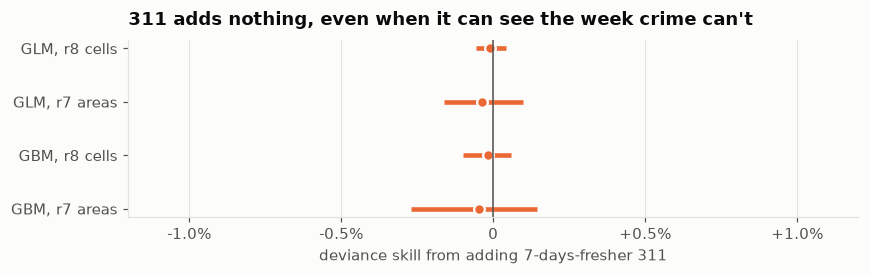

In [9]:
ls = pl.read_csv(WEEK_MODEL / "local_summary.csv")
print(ls.filter(pl.col("year") == "all").drop("year"))

# The 311 test: the same model with and without the fresher 311 features, paired on the same folds.
from backtest import skill_ci
lp = pl.read_parquet(WEEK_MODEL / "local_predictions.parquet")
lp7 = lp.group_by("h3_r7", "cutoff", "fold").agg(pl.col("y", "glm_crime", "gbm_crime", "glm_crime_311", "gbm_crime_311").sum())
lift = [(f"{m.upper()}, {g}", *skill_ci(df, f"{m}_crime_311", f"{m}_crime"))
        for m in ("glm", "gbm") for g, df in (("r8 cells", lp), ("r7 areas", lp7))]
fig, ax = plt.subplots(figsize=(8, 2.6))
forest(ax, [l[0] for l in lift], [l[1] for l in lift], [l[2] for l in lift], [l[3] for l in lift], color=ORANGE)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.1%}" if v else "0"))
ax.set_xlim(-0.012, 0.012)
ax.set_xlabel("deviance skill from adding 7-days-fresher 311")
ax.set_title("311 adds nothing, even when it can see the week crime can't")
fig.tight_layout()

- **The local model adds a small, steady gain:** +1.3% at r8 (CI +1.1 to +1.5%) and +2.4% summed to r7, positive
  every year. It's smaller than the 4-week track's +3.6%, because a week is noisier: 78% of an r8 cell's weekly miss
  is chance.
- **The GLM beats the trees again.** Its main levers: cells with a higher bar come in lower (regression to the mean),
  the last 28 days push the forecast up, neighbors push a little, and last year's rise predicts a partial fall back.
- **Fresher 311 adds nothing.** Every interval sits on zero, and the GLM's is tight enough (±0.05% at r8) to rule
  out anything meaningful. That's the second careful null for 311 as a forecast input.
- **Raw 28-day momentum ranks above-normal places slightly better than the GLM** (below). The GLM is better at the
  size of the departure, which deviance rewards. The 4-week track showed the same split.

In [10]:
pl.read_csv(WEEK_MODEL / "local_ranking.csv")

grain,ranked_by,auc_above_normal,ci_lo,ci_hi
str,str,f64,f64,f64
"""r8""","""glm_crime""",0.532,0.527,0.536
"""r8""","""momentum_28d""",0.537,0.533,0.540
"""r8""","""momentum_7d""",0.526,0.522,0.529
"""r7""","""glm_crime""",0.549,0.537,0.560
"""r7""","""momentum_28d""",0.564,0.554,0.574
"""r7""","""momentum_7d""",0.543,0.535,0.552


## 6. Step 4: a forecast and a call for each community area

`area_week.py` works at the grain the app shows:
- **An area's normal** is its own calibrated bar, built from its own crime records.
- **Every forecast** is that normal × step 2's citywide call × a local lean. Five leans are compared:
  - `bar_city`: none
  - `cells_summed`: step 3's cells split into areas by their 2016–2021 crime share
  - `cells_tilt`: those cells' lean on the area's own level
  - `native_glm`: a GLM fit on the areas directly
  - `momentum`: one feature, the last 28 known days vs the trailing year
- **Calls:** a negative binomial around the forecast gives P(next week > normal). Its dispersion comes from earlier
  folds only. Up at P ≥ 0.65, down at P ≤ 0.35.
- **Relative calls** ask whether an area will beat `bar_city`, i.e. outpace what the citywide call implies for it.
  They isolate what the local lean can call on its own.

In [11]:
print(pl.read_csv(WEEK_MODEL / "area_comparison.csv").select("option", "skill_vs_normal", "skill_vs_bar_city", "lo_c", "hi_c", "auc"))
calls = pl.read_csv(WEEK_MODEL / "area_calls.csv")
calls.select("call_vs", "forecast", "brier_skill", "share_called", "hit_rate", "hit_lo", "hit_hi",
             "weeks_with_a_call", "median_calls_per_week")

┌──────────────┬─────────────────┬───────────────────┬───────┬───────┬───────┐
│ option       ┆ skill_vs_normal ┆ skill_vs_bar_city ┆ lo_c  ┆ hi_c  ┆ auc   │
│ ---          ┆ ---             ┆ ---               ┆ ---   ┆ ---   ┆ ---   │
│ str          ┆ f64             ┆ f64               ┆ f64   ┆ f64   ┆ f64   │
╞══════════════╪═════════════════╪═══════════════════╪═══════╪═══════╪═══════╡
│ bar_city     ┆ 0.118           ┆ 0.000             ┆ 0.000 ┆ 0.000 ┆ 0.501 │
│ cells_summed ┆ 0.132           ┆ 0.016             ┆ 0.001 ┆ 0.029 ┆ 0.570 │
│ cells_tilt   ┆ 0.139           ┆ 0.024             ┆ 0.010 ┆ 0.037 ┆ 0.575 │
│ native_glm   ┆ 0.145           ┆ 0.032             ┆ 0.021 ┆ 0.044 ┆ 0.577 │
│ momentum     ┆ 0.144           ┆ 0.030             ┆ 0.022 ┆ 0.039 ┆ 0.580 │
└──────────────┴─────────────────┴───────────────────┴───────┴───────┴───────┘


call_vs,forecast,brier_skill,share_called,hit_rate,hit_lo,hit_hi,weeks_with_a_call,median_calls_per_week
str,str,f64,f64,f64,f64,f64,f64,f64
"""normal""","""bar_city""",0.079,0.186,0.746,0.692,0.786,0.351,0.000
"""normal""","""cells_summed""",0.088,0.285,0.728,0.692,0.763,1.000,14.000
"""normal""","""cells_tilt""",0.092,0.243,0.747,0.704,0.785,0.978,9.000
"""normal""","""native_glm""",0.092,0.252,0.738,0.695,0.772,0.957,10.000
"""normal""","""momentum""",0.094,0.234,0.745,0.701,0.780,0.905,6.000
"""relative""","""cells_summed""",0.016,0.077,0.633,0.603,0.664,1.000,6.000
"""relative""","""cells_tilt""",0.022,0.022,0.655,0.585,0.728,0.823,2.000
"""relative""","""native_glm""",0.021,0.020,0.652,0.605,0.695,0.779,1.000
"""relative""","""momentum""",0.022,0.014,0.737,0.690,0.794,0.619,1.000


- **Area calls are much better than the 4-week track's.** There, 8% of r7 area-months got a call, right ~68% of the
  time against a 53% base rate, with 4% Brier skill. Here, 23% of area-weeks get a call, right 75% of the time
  against 48%, with 9.4% Brier skill.
- **Most of it is the citywide call.** `bar_city` alone calls 19% of area-weeks at the same accuracy.
- **The cell model isn't needed for areas.** Area-level models match or beat the cells rolled up, and splitting cells
  across area lines costs accuracy (`cells_summed` is worst).
- **Momentum drives the calls.** It has the best Brier and AUC, is tied on deviance, and is one feature. So the local
  reason can be as plain as "its last 4 weeks ran X% above normal."

The next chart shows why the hit rates get CIs from resampling whole quarters, not rows. Calls cluster in the weeks
with a strong citywide call:

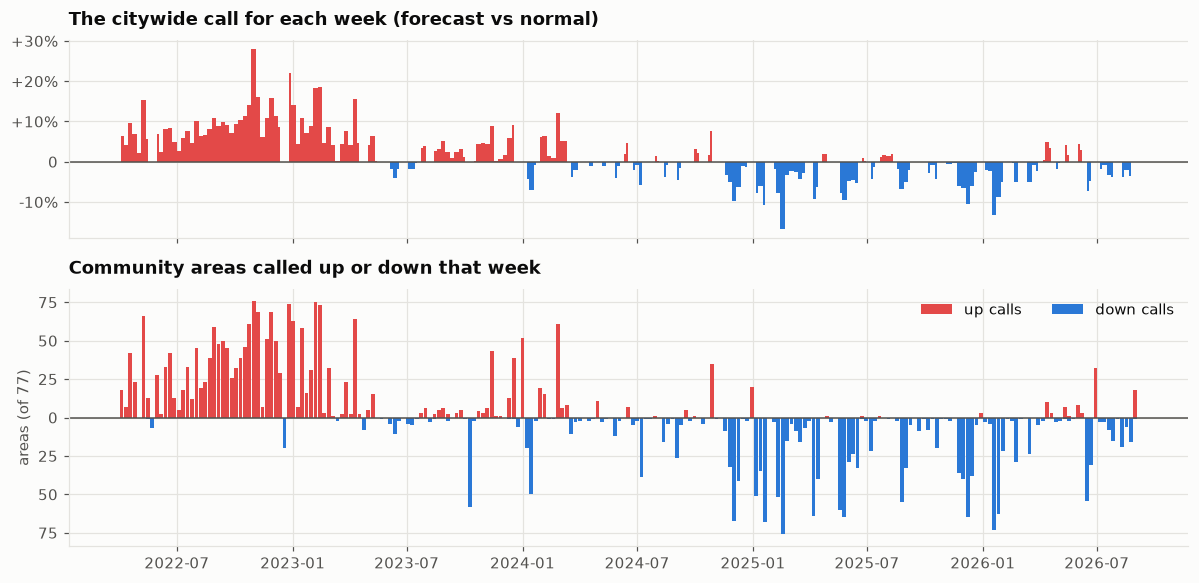

In [12]:
from area_week import cell_area_shares
probs = pl.read_parquet(WEEK_MODEL / "area_test_probs.parquet")
per_week = probs.group_by("cutoff").agg(
    pl.col("pct_citywide").first(), (pl.col("call") == "up").sum().alias("up"), (pl.col("call") == "down").sum().alias("down")
).sort("cutoff")
x, city_call = per_week["cutoff"], per_week["pct_citywide"].to_numpy()
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True, gridspec_kw={"height_ratios": [1, 1.3]})
a1.fill_between(x, 0, city_call, where=city_call > 0, color=UP, lw=0, step="mid")
a1.fill_between(x, 0, city_call, where=city_call < 0, color=DOWN, lw=0, step="mid")
a1.axhline(0, color=INK_2, lw=1)
a1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}" if v else "0"))
a1.set_title("The citywide call for each week (forecast vs normal)")
a2.bar(x, per_week["up"], color=UP, width=6, label="up calls")
a2.bar(x, -per_week["down"].cast(pl.Int32), color=DOWN, width=6, label="down calls")
a2.axhline(0, color=INK_2, lw=1)
a2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{abs(v):.0f}"))
a2.set_ylabel("areas (of 77)")
a2.set_title("Community areas called up or down that week")
a2.legend(loc="upper right", ncols=2)
fig.tight_layout()

When the citywide call is strong, dozens of areas get the same call. Calls in the same week share one citywide
forecast, so they stand or fall together. Across 244 weeks, that averages out to the 75%.

The probabilities, pooled over every test area-week (bins with at least 100 rows):

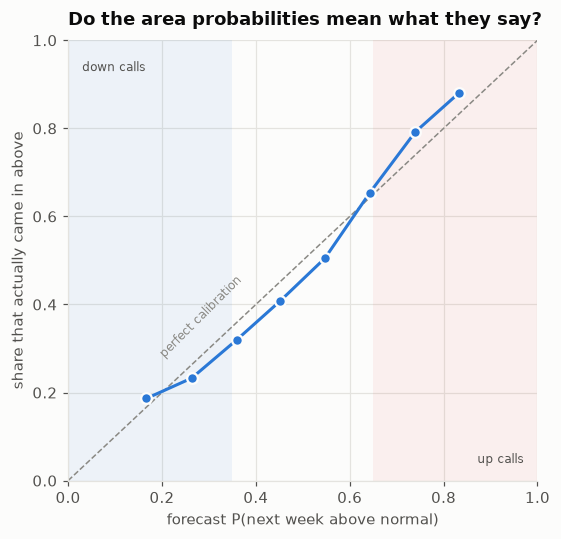

In [13]:
rel = pl.read_csv(WEEK_MODEL / "area_reliability.csv").filter((pl.col("forecast") == "momentum") & (pl.col("n") >= 100))
fig, ax = plt.subplots(figsize=(5.2, 5.0))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--")
ax.text(0.19, 0.28, "perfect calibration", color=MUTED, fontsize=8, rotation=45)
ax.axvspan(0.65, 1, color=UP, alpha=0.07, lw=0)
ax.axvspan(0, 0.35, color=DOWN, alpha=0.07, lw=0)
ax.text(0.97, 0.04, "up calls", color=INK_2, fontsize=8, ha="right")
ax.text(0.03, 0.93, "down calls", color=INK_2, fontsize=8)
ax.plot(rel["predicted"], rel["observed"], "-o", color=BLUE, ms=7, mec=SURFACE, mew=1.5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel("forecast P(next week above normal)")
ax.set_ylabel("share that actually came in above")
ax.set_title("Do the area probabilities mean what they say?")
fig.tight_layout()

In the middle range, predicted runs ~4 points above observed. Above 0.65, observed runs 1–5 points above predicted,
so the up calls are, if anything, conservative.

### One week on the map

The last test week, beginning 2026-08-31. Community-area polygons aren't in the offline data, so each r8 cell is
painted with the call for the area holding most of its crime. That's close enough to see the shape.

area_name,normal,forecast,pct_citywide,pct_local,p_above,call,y
str,f64,f64,f64,f64,f64,str,u32
"""Austin""",243.542,263.464,0.056,0.025,0.730,"""up""",225
"""South Shore""",173.261,187.357,0.056,0.024,0.713,"""up""",156
"""Humboldt Park""",128.692,139.331,0.056,0.026,0.712,"""up""",107
"""Auburn Gresham""",121.471,130.940,0.056,0.021,0.695,"""up""",125
"""Near West Side""",221.472,236.132,0.056,0.010,0.686,"""up""",188
"""South Lawndale""",75.595,81.757,0.056,0.024,0.684,"""up""",58
"""West Englewood""",91.109,98.656,0.056,0.026,0.683,"""up""",87
"""Near South Side""",48.104,52.927,0.056,0.042,0.676,"""up""",44


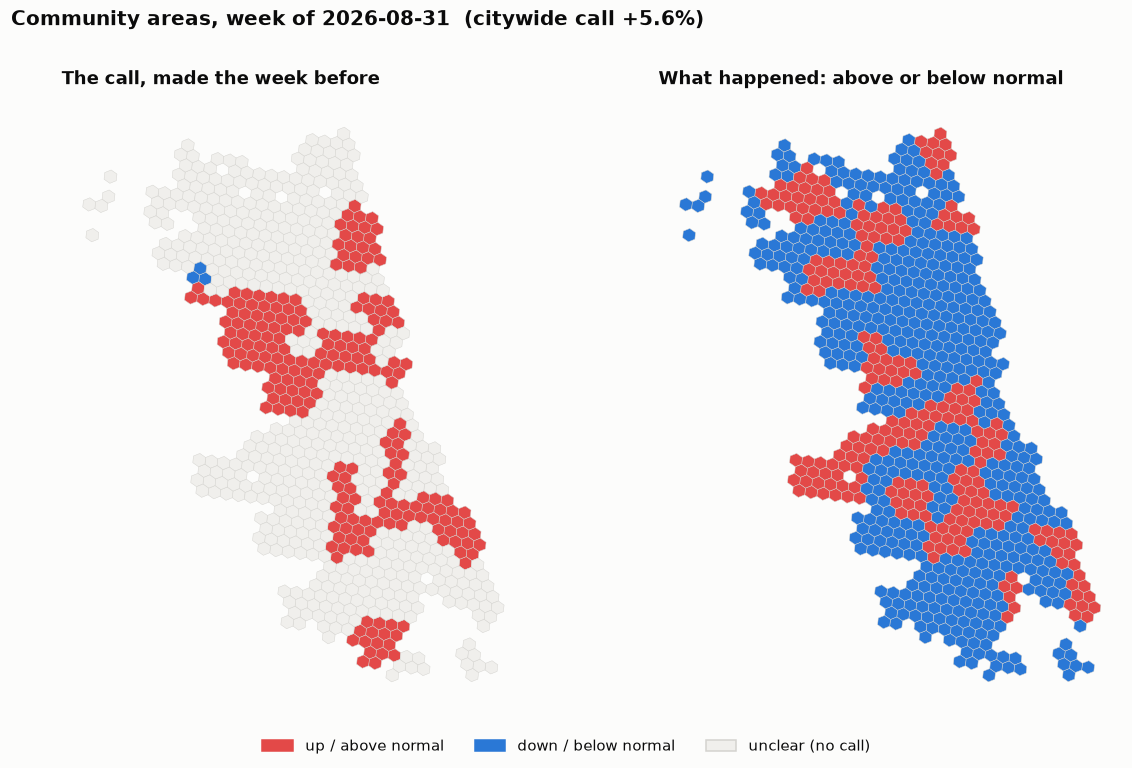

In [14]:
shares = cell_area_shares()
main_area = shares.sort("share", descending=True).group_by("h3_r8").first().select("h3_r8", pl.col("community_area").cast(pl.Int64))
week = probs.filter(pl.col("cutoff") == probs["cutoff"].max())
m = main_area.join(week, on="community_area")
color_of = {"up": UP, "down": DOWN, "unclear": NEUTRAL}
fig, axes = plt.subplots(1, 2, figsize=(11, 7))
hex_map(axes[0], m["h3_r8"], [color_of[c] for c in m["call"]], edge="#d4d3cf", lw=0.3)
axes[0].set_title("The call, made the week before")
hex_map(axes[1], m["h3_r8"], [UP if a else DOWN for a in m["above"]], edge="#d4d3cf", lw=0.3)
axes[1].set_title("What happened: above or below normal")
fig.legend(handles=[Patch(color=UP, label="up / above normal"), Patch(color=DOWN, label="down / below normal"),
                    Patch(facecolor=NEUTRAL, edgecolor="#d4d3cf", label="unclear (no call)")],
           loc="lower center", ncols=3)
fig.suptitle(f"Community areas, week of {week['cutoff'][0]}  (citywide call {week['pct_citywide'][0]:+.1%})",
             x=0.02, ha="left", fontweight="semibold", fontsize=13)
fig.tight_layout(rect=(0, 0.05, 1, 0.95))

week.sort("p_above", descending=True).select(
    "area_name", "normal", "forecast", "pct_citywide", "pct_local", "p_above", "call", "y").head(8)

An honest example, not a flattering one. The citywide call was +5.6%, the city came in below normal, and 4 of the top 5
up calls missed. This is what "calls stand or fall together" looks like in a single week. The table is also the
shape the app would read: normal, forecast, P(above), the call, and its reason split into a citywide part and a local
part.

## 7. What we learned, and what's next

**What the numbers say:**
1. **The question matters as much as the model.** "Up vs last week" is mostly regression to the mean. "Above its own
   normal" is the honest target.
2. **At one week, the city's level is the biggest predictable piece.** Momentum, holidays and the 1–7 day weather
   forecast win most of it, and forecast weather is nearly as good as perfect weather.
3. **The local lean is real but small.** It's a few % of deviance, and on its own it calls about one area a week.
   Plain 28-day momentum does as well as any model.
4. **311 still adds nothing,** even with a week's head start on crime.

**Before this goes in the app:**
- **A fresh crime pull.** The export ends 2026-09-11. After that, a live run is city_level → area_week on the newest
  cutoff, with that week's weather forecast.
- **A late-report correction** of ~1.5% on the newest week's counts.
- **A UI decision.** Since most calls are citywide, lead with a city outlook ("next week runs hot: warm forecast, rising
  trend"), then show each area's call as that plus its own lean.

**Worth trying next:**
- **Known events as a local feature.** The biggest cell-week spikes are Lollapalooza (~300 crimes vs a normal of
  ~20–36, mostly pickpocketing in Grant Park), and the events work already has the permits.
- **Separate targets** for violent, property and enforcement-driven crime.

**Caveats:**
- Crime counts reflect reporting and enforcement, not only victimization.
- The test covers 2022–2026 only: 244 weeks, and 18 quarters of calls.
- Weather comes from one point in the city. The forecast archive only covers the test years, so the weather effect is
  learned on observed weather and applied to forecasts.